# Compute properties from known data

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

In [14]:
test_id = '130T225L25'
width_proxy_test_id = '110T218L25' # From 110T225L25 case in Lewellen 2014part 1
depth_proxy_test_id = '110T218L25'

# IWC

In [15]:
# Import contrail depth from digitized LLES data
LES_contrail_depths = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_depth/{width_proxy_test_id}_D.csv", header=None)
# Import contrail width from digitized LLES data
LES_contrail_widths = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_width/{width_proxy_test_id}_W.csv", header=None)
# Import ice mass from digitized LLES data
LLES_ice_mass_data = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_mass/{test_id}.csv", header=None)

times = np.linspace(0, 12, num=73)  # Time in hours from 0 to 12 hours, 73 points

LLES_ice_mass_interp = interp1d(LLES_ice_mass_data[0], LLES_ice_mass_data[1], kind='linear')(times)
LLES_depth = interp1d(LES_contrail_depths[0], LES_contrail_depths[1], kind='linear')(times)
LLES_width = interp1d(LES_contrail_widths[0], LES_contrail_widths[1], kind='linear')(times)

LLES_area = 0.5*(LLES_depth * LLES_width)*np.pi

LLES_iwc = LLES_ice_mass_interp / LLES_area * 1e3 # [kg/m]/[m2] * 1e3 = [g/m3]

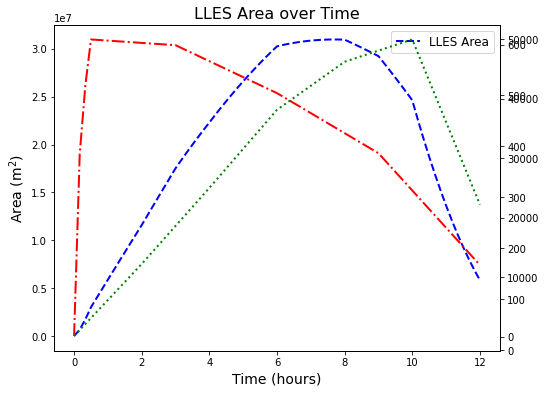

In [16]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(times, LLES_area, label='LLES Area', color='blue', linestyle='--', lw=2)

ax2 = ax.twinx()
ax2.plot(times, LLES_depth, label='LLES Depth', color='red', linestyle='-.', lw=2)

ax3 = ax.twinx()
ax3.plot(times, LLES_width, label='LLES Width', color='green', linestyle=':', lw=2)

ax.set_xlabel('Time (hours)', fontsize=14)
ax.set_ylabel('Area (m$^2$)', fontsize=14)
ax.set_title('LLES Area over Time', fontsize=16)
ax.legend(fontsize=12)
plt.show()

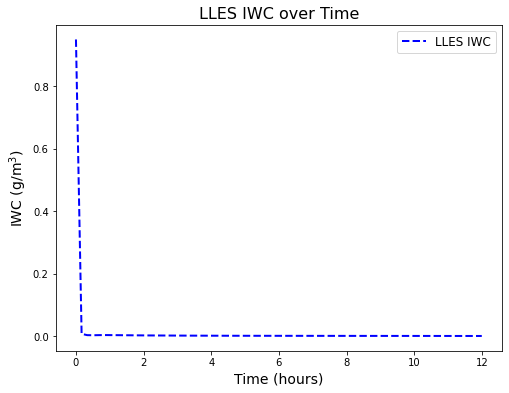

In [17]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(times, LLES_iwc, label='LLES IWC', color='blue', linestyle='--', lw=2)
ax.set_xlabel('Time (hours)', fontsize=14)
ax.set_ylabel('IWC (g/m$^3$)', fontsize=14)
ax.set_title('LLES IWC over Time', fontsize=16)
ax.legend(fontsize=12)
plt.show()

In [18]:
# Save the LLES IWC data to a CSV file
LLES_iwc_df = pd.DataFrame({'Time_hours': times, 'IWC_g_per_m3': LLES_iwc})
LLES_iwc_df.to_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/IWC/{test_id}_IWC.csv", index=False)